# Dupor (2023) household: minimal demo

Solve and simulate the infinite-horizon, separable-utility, Markov-income household,
then plot the ergodic cross-section of market resources, consumption, and labor supply.

In [1]:
import os, sys, importlib.util
import numpy as np
import matplotlib.pyplot as plt

HERE = os.path.dirname(os.path.abspath("dupor_minimal_demo.ipynb")) or os.getcwd()

# Make sure HARK's internal `from interpolation import interp` doesn't get
# shadowed by the local `interpolation.py` in this folder.
sys.path = [p for p in sys.path if os.path.abspath(p) != os.path.abspath(HERE)]

def _load_local(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod

_load_local("rewards", os.path.join(HERE, "rewards.py"))
cl = _load_local("ConsLaborModelSep", os.path.join(HERE, "ConsLaborModel copy.py"))
LaborIntMargSepMrkvConsumerType = cl.LaborIntMargSepMrkvConsumerType

In [2]:
agent = LaborIntMargSepMrkvConsumerType(cycles=0, T_cycle=1)
agent.solve()

agent.AgentCount = 5000
agent.T_sim = 500
agent.initialize_sim()
agent.simulate()

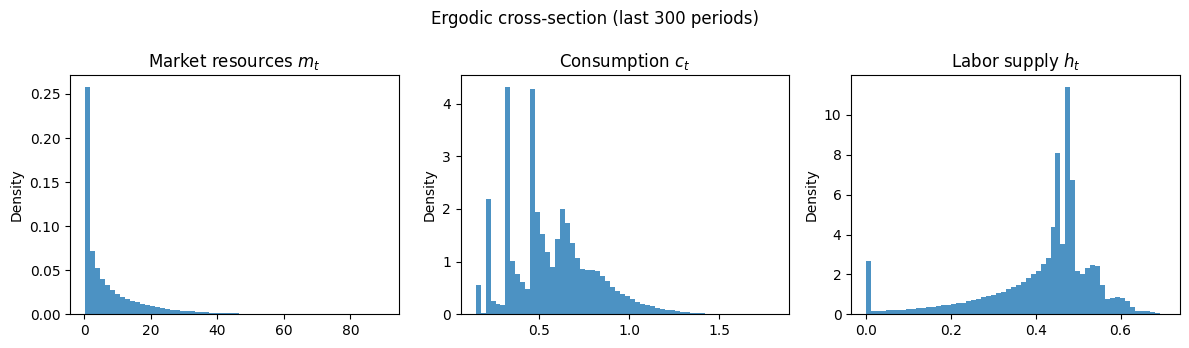

In [3]:
burn_in = 200
mLvl = agent.history["mLvl"][burn_in:, :].ravel()
cLvl = agent.history["cLvl"][burn_in:, :].ravel()
Lbr  = agent.history["Lbr"][burn_in:, :].ravel()

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, data, name in zip(
    axes,
    [mLvl, cLvl, Lbr],
    [r"Market resources $m_t$", r"Consumption $c_t$", r"Labor supply $h_t$"],
):
    ax.hist(data, bins=60, density=True, alpha=0.8)
    ax.set_title(name)
    ax.set_ylabel("Density")
fig.suptitle("Ergodic cross-section (last {} periods)".format(agent.T_sim - burn_in))
fig.tight_layout()
plt.show()

## Sequence-Space Jacobian: consumption response to a fiscal-transfer shock

Compute $\mathcal{J}^{C,\mathcal{T}}_{t,s} = \partial C_t / \partial \mathcal{T}_s$ around the stationary equilibrium using HARK's built-in fake-news algorithm (Auclert–Bardóczy–Rognlie–Straub) via `HARK.SSJutils.make_basic_SSJ_matrices`.

HARK needs a YAML model statement to build its symbolic simulator (`agent.initialize_sym()` → `agent._simulator`). The local file `ConsLaborIntMargSepMrkv.yaml` is auto-loaded by the class into `agent.model_statement`, so HARK never has to look inside the installed package. The wrapper `agent.make_SSJ(...)` fills in sensible default grids and forwards everything to `make_basic_SSJ_matrices`.

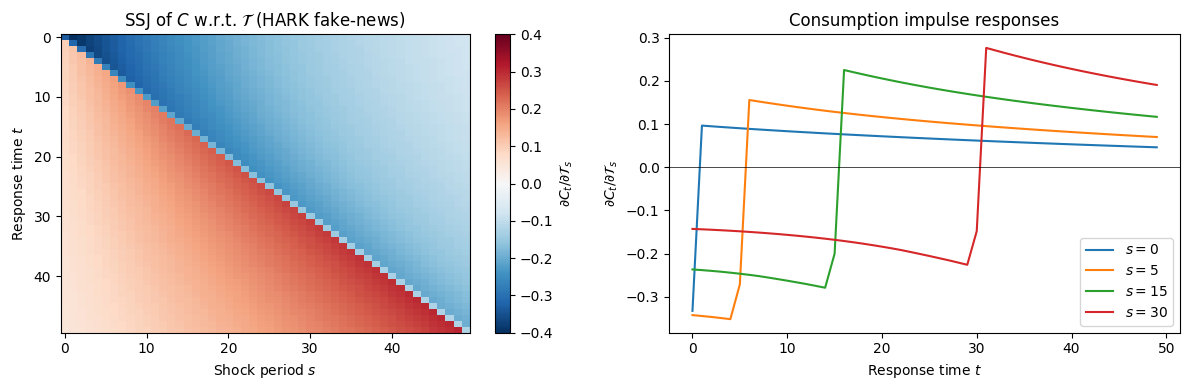

In [4]:
# SSJ via HARK's fake-news algorithm
# ==================================
#
# `agent.make_SSJ(...)` is a thin wrapper around
# `HARK.SSJutils.make_basic_SSJ_matrices`
# (Auclert-Bardoczy-Rognlie-Straub). It:
#   1. builds HARK's symbolic simulator from `agent.model_statement`
#      (loaded from the local `ConsLaborIntMargSepMrkv.yaml`);
#   2. solves the long-run / steady-state model;
#   3. builds discrete transition matrices on the user-supplied grids;
#   4. perturbs the named shock parameter and runs the fake-news algorithm.
#
# Everything below uses HARK utilities -- the only inputs are the shock name,
# the outcome name, and an optional T_max.

T_max = 50

SSJ_cT = agent.make_SSJ(
    shock="Rfree",       # parameter to perturb
    outcomes="cLvl",      # response variable
    T_max=T_max,
    eps=1e-3,
    verbose=False,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
vmax = float(np.max(np.abs(SSJ_cT))) or 1.0
im = axes[0].imshow(SSJ_cT, aspect="auto", cmap="RdBu_r",
                    vmin=-vmax, vmax=vmax)
plt.colorbar(im, ax=axes[0],
             label=r"$\partial C_t / \partial \mathcal{T}_s$")
axes[0].set_xlabel(r"Shock period $s$")
axes[0].set_ylabel(r"Response time $t$")
axes[0].set_title(r"SSJ of $C$ w.r.t. $\mathcal{T}$ (HARK fake-news)")
for s_plot in (0, 5, 15, 30):
    axes[1].plot(range(T_max), SSJ_cT[:, s_plot], label=f"$s = {s_plot}$")
axes[1].axhline(0, color="k", lw=0.5)
axes[1].set_xlabel(r"Response time $t$")
axes[1].set_ylabel(r"$\partial C_t / \partial \mathcal{T}_s$")
axes[1].set_title("Consumption impulse responses")
axes[1].legend()
fig.tight_layout()
plt.show()
